In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

file = "../../data/HCMST 2017 to 2022 small public version 2.2.dta"
df = pd.read_stata(file)

/var/folders/vp/lwy9wn811sj3bwmkzg6q0rgm0000gn/T/ipykernel_15613/3661410484.py:11: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata(file)


In [3]:
df['w1_ppeduc'].value_counts()

w1_ppeduc
HIGH SCHOOL GRADUATE - high school DIPLOMA or the equivalent (GED)    932
Bachelors degree                                                      709
Some college, no degree                                               677
Masters degree                                                        404
Associate degree                                                      352
Professional or Doctorate degree                                      150
11th grade                                                             76
12th grade NO DIPLOMA                                                  65
10th grade                                                             64
9th grade                                                              34
7th or 8th grade                                                       26
5th or 6th grade                                                       11
No formal education                                                     7
1st, 2nd, 3rd, or 4th grade 

In [4]:
df['w1_q10'].value_counts()

w1_q10
HS graduate or GED                  833
Bachelors degree                   734
Some college, no degree             726
Masters degree                     367
Associate degree                    331
Professional or Doctorate degree    152
12th grade no diploma               108
10th grade                           36
11th grade                           31
9th grade                            19
7th or 8th grade                     18
Refused                              11
5th or 6th grade                     11
No formal education                   9
1st-4th grade                         8
Name: count, dtype: int64

In [5]:

# 1. Feature Engineering: Transforming your raw fields into "Relationship Traits"
# We compare the Respondent and Partner to see how they match/differ
# List of raw variables based on your selected fields
raw_fields = [
    'w1_ppage', 'w1_q9',              # Ages
    'w1_ppeduc', 'w1_q10',            # Education
    'w1_ppincimp',                    # Household Income
    'w1_partyid7', 'w1_q12',          # Politics
    'w1_ppp20072',                    # Religion
    'w1_subject_race', 'w1_q6b',      # Race/Ethnicity
    'w1_weight_combo'                 # Weights (Crucial!)
]

# Create a clean working copy
data = df[raw_fields].copy()

# Age Gap
data['age_gap'] = np.abs(pd.to_numeric(data['w1_ppage'], errors='coerce') - 
                         pd.to_numeric(data['w1_q9'], errors='coerce'))

In [6]:
#Mapping for Education Levels:
def standardize_edu(text):
    text = str(text).lower().strip()
    if any(x in text for x in ['doctorate', 'professional', 'master']):
        return 6 # Post-Grad
    elif 'bachelor' in text:
        return 5
    elif 'associate' in text:
        return 4
    elif 'some college' in text:
        return 3
    elif any(x in text for x in ['high school graduate', 'hs graduate', 'equivalent']):
        return 2
    elif any(x in text for x in ['grade', 'no formal', 'no diploma']):
        return 1
    return 0 # Missing/Refused

# Apply the mapping
data['res_edu_std'] = data['w1_ppeduc'].apply(standardize_edu)
data['part_edu_std'] = data['w1_q10'].apply(standardize_edu)

# Now create the match
data['edu_match'] = (data['res_edu_std'] == data['part_edu_std']).astype(int)

# Optional: Calculate 'Education Gap' (Directional)
# Positive means Respondent is more educated, negative means Partner is.
data['edu_gap'] = data['res_edu_std'] - data['part_edu_std']

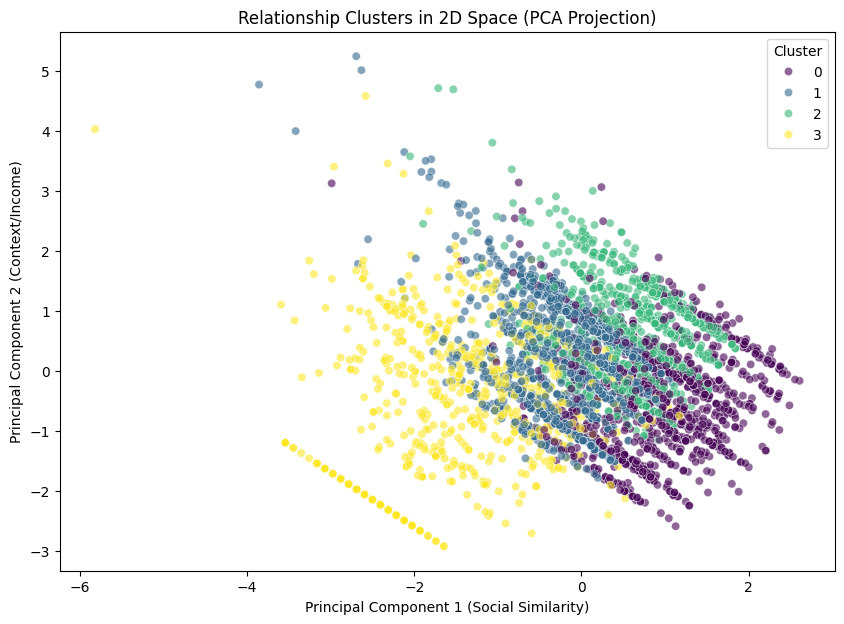

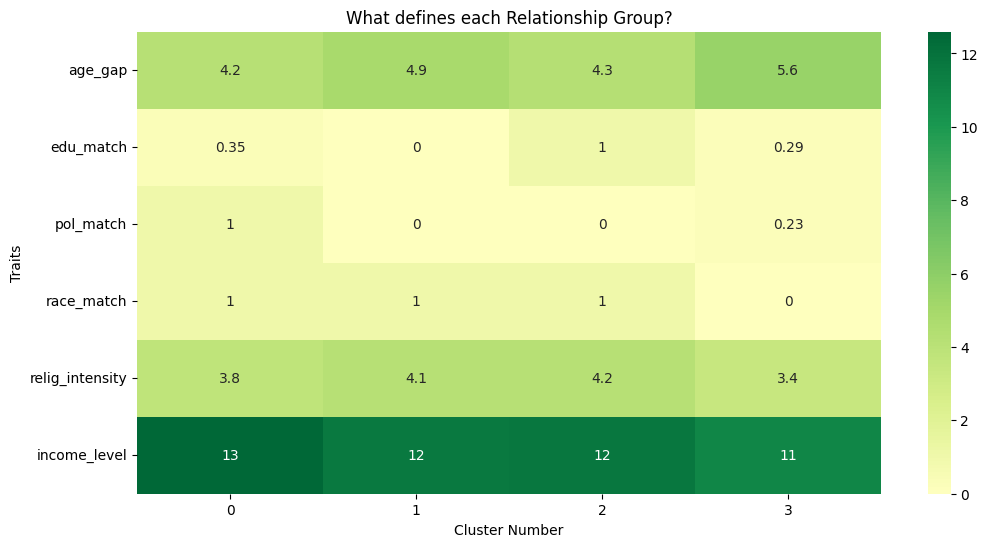

In [7]:
# Matches (1 if same, 0 if different)
data['pol_match'] = (data['w1_partyid7'].astype(str) == data['w1_q12'].astype(str)).astype(int)
data['race_match'] = (data['w1_subject_race'].astype(str) == data['w1_q6b'].astype(str)).astype(int)

# Religious Intensity (Attendance frequency)
data['relig_intensity'] = data['w1_ppp20072'].cat.codes if hasattr(data['w1_ppp20072'], 'cat') else 0

# Socio-Economic & Geography (Converting categories to numbers for the algorithm)
data['income_level'] = data['w1_ppincimp'].cat.codes if hasattr(data['w1_ppincimp'], 'cat') else 0

# 2. Prepare Data for Clustering
# These are the items that will define the "Story" of each group
clustering_features = [
    'age_gap', 'edu_match', 'pol_match', 'race_match', 
    'relig_intensity', 'income_level'
]

X = data[clustering_features]

# Handle missing values and Scale
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. Run KMeans Clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Visualization A: The "Normal" Clustering Chart (PCA Scatter Plot)
# This squashes all your variables into 2 dimensions so you can see the groups
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
data['pca_1'] = pca_data[:, 0]
data['pca_2'] = pca_data[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', data=data, palette='viridis', alpha=0.6)
plt.title('Relationship Clusters in 2D Space (PCA Projection)')
plt.xlabel('Principal Component 1 (Social Similarity)')
plt.ylabel('Principal Component 2 (Context/Income)')
plt.legend(title='Cluster')
plt.show()

# 5. Visualization B: The Storyteller (Profile Heatmap)
# This includes every item you listed to show exactly what each group looks like
profile = data.groupby('cluster')[clustering_features].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(profile.T, annot=True, cmap='RdYlGn', center=0)
plt.title('What defines each Relationship Group?')
plt.xlabel('Cluster Number')
plt.ylabel('Traits')
plt.show()

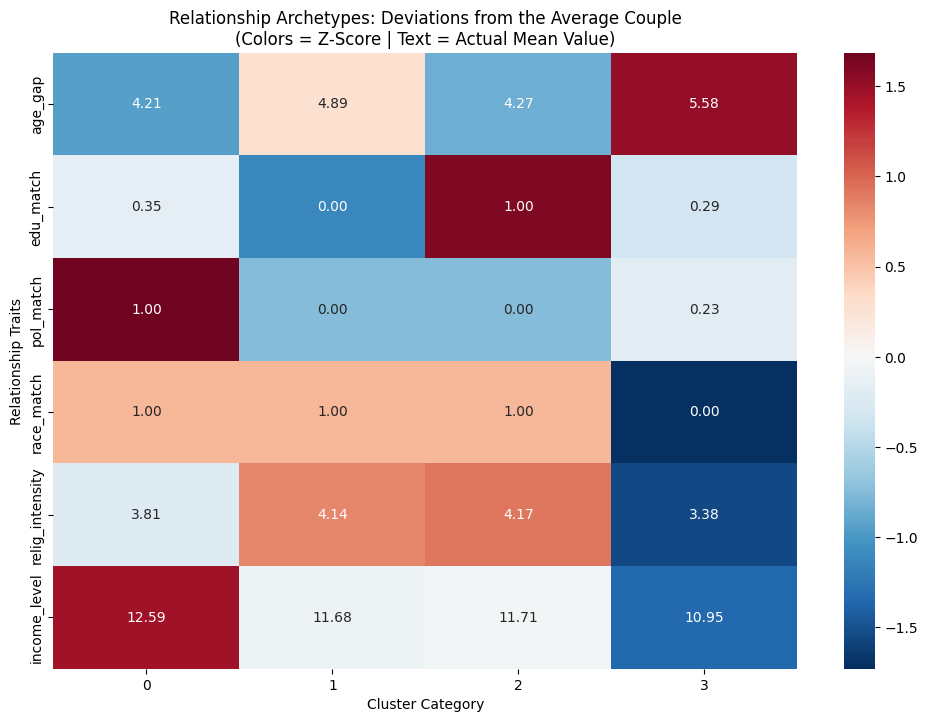

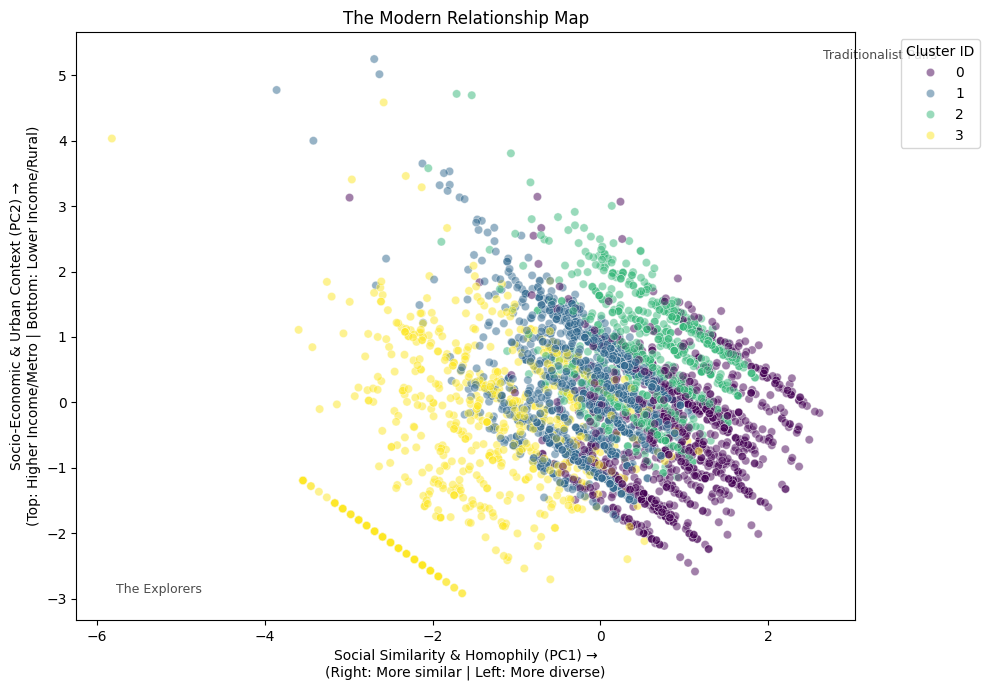

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# --- STEP 1: CALCULATE Z-SCORES FOR HEATMAP ---
# This scales each row so that 0 is the "Average" relationship
# Red/Blue will show what is "Higher" or "Lower" than normal for that cluster
profile_data = data.groupby('cluster')[clustering_features].mean()
profile_zscribed = profile_data.apply(zscore)

# --- STEP 2: PLOT STANDARDIZED HEATMAP ---
plt.figure(figsize=(12, 8))
sns.heatmap(profile_zscribed.T, annot=profile_data.T, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Relationship Archetypes: Deviations from the Average Couple\n(Colors = Z-Score | Text = Actual Mean Value)')
plt.xlabel('Cluster Category')
plt.ylabel('Relationship Traits')
plt.show()

# --- STEP 3: PLOT PCA WITH DESCRIPTIVE AXES ---
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', data=data, palette='viridis', alpha=0.5)

# Naming the axes based on typical HCMST loadings
plt.title('The Modern Relationship Map')
plt.xlabel('Social Similarity & Homophily (PC1) →\n(Right: More similar | Left: More diverse)')
plt.ylabel('Socio-Economic & Urban Context (PC2) →\n(Top: Higher Income/Metro | Bottom: Lower Income/Rural)')

# Add annotations for the "Story"
plt.text(data['pca_1'].max(), data['pca_2'].max(), ' Traditionalist Pairs', fontsize=9, alpha=0.7)
plt.text(data['pca_1'].min(), data['pca_2'].min(), ' The Explorers', fontsize=9, alpha=0.7)

plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Cluster 0 (The Deep Red in pol_match): This is your "Ideological Fortress" cluster. They have a perfect political match (1.00) which is significantly higher than the average. They also have a very high income relative to others.

Cluster 3 (The Deep Red in age_gap and Deep Blue in race_match): This is your "Boundary Crossers" cluster. They have the highest age gap (5.58) and the lowest racial similarity (0.00). This is a very distinct profile of people who are open to "non-traditional" matching.

Cluster 2 (The Deep Red in edu_match): These are "Academic Peers." They prioritize having the exact same education level (1.00) but are very "average" or even mismatched in politics.

## Comparison

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter for the longitudinal sample (those with Wave 3 data)
long_df = df[df['w3_section'].notna()].copy()

# 2. Define the Orientation Groups (LGB vs Straight)
long_df['orientation'] = long_df['w1_identity_all_modified'].apply(
    lambda x: 'LGB' if any(i in str(x).lower() for i in ['gay', 'lesbian', 'bisexual']) else 'Straight'
)

# 3. Standardization: Recalculating your Match Logic for this slice
long_df['pol_match'] = (long_df['w1_partyid7'].astype(str) == long_df['w1_q12'].astype(str)).astype(int)
long_df['race_match'] = (long_df['w1_subject_race'].astype(str) == long_df['w1_q6b'].astype(str)).astype(int)

# Use your mapping from earlier
long_df['res_edu_std'] = long_df['w1_ppeduc'].apply(standardize_edu)
long_df['part_edu_std'] = long_df['w1_q10'].apply(standardize_edu)
long_df['edu_match'] = (long_df['res_edu_std'] == long_df['part_edu_std']).astype(int)

# 4. Map Quality Scores using the correct variable names
# Wave 1: w1_q34 | Wave 2: w2_rel_qual_combo | Wave 3: w3_rel_qual
quality_map = {'Excellent': 5, 'Very Good': 4, 'Good': 3, 'Fair': 2, 'Poor': 1, 'Very Poor': 1}

long_df['q_w1'] = long_df['w1_q34'].map(quality_map)
long_df['q_w2'] = long_df['w2_rel_qual_combo'].map(quality_map)
long_df['q_w3'] = long_df['w3_rel_qual'].map(quality_map)

# Drop missing values for a clean line chart
long_df_clean = long_df.dropna(subset=['q_w1', 'q_w3', 'orientation'])

/var/folders/vp/lwy9wn811sj3bwmkzg6q0rgm0000gn/T/ipykernel_15613/1738438308.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=long_df_clean, x='orientation', y='match_density', palette='coolwarm')


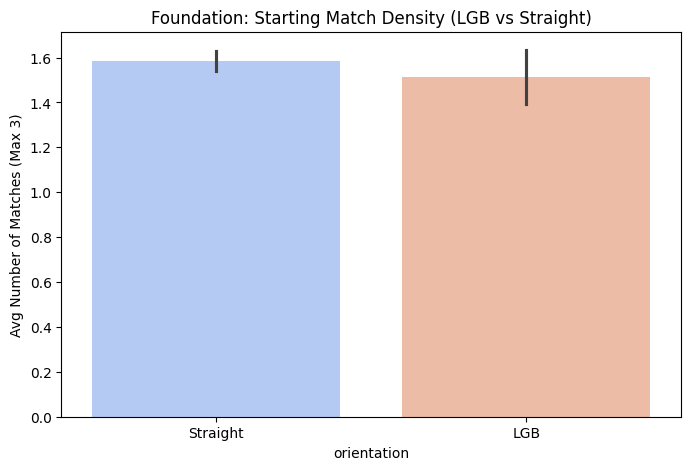

In [10]:
# Match Density (How many of the 3 key traits did they share?)
long_df_clean['match_density'] = long_df_clean[['pol_match', 'edu_match', 'race_match']].sum(axis=1)

plt.figure(figsize=(8, 5))
sns.barplot(data=long_df_clean, x='orientation', y='match_density', palette='coolwarm')
plt.title('Foundation: Starting Match Density (LGB vs Straight)')
plt.ylabel('Avg Number of Matches (Max 3)')
plt.show()

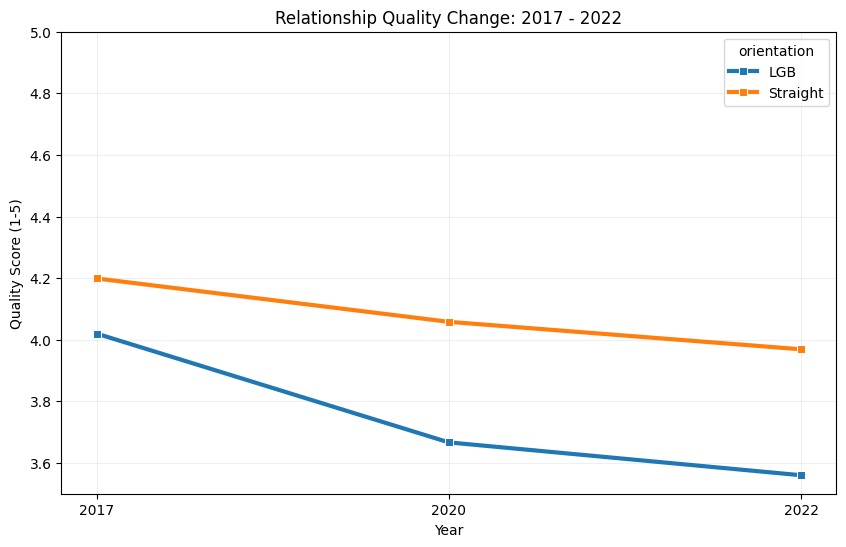

In [11]:
# Aggregate the means
traj = long_df_clean.groupby('orientation')[['q_w1', 'q_w2', 'q_w3']].mean().reset_index()

# Melt for Seaborn lineplot
traj_long = pd.melt(traj, id_vars=['orientation'], value_vars=['q_w1', 'q_w2', 'q_w3'],
                    var_name='Wave', value_name='Quality')

# Map to years
traj_long['Year'] = traj_long['Wave'].map({'q_w1': '2017', 'q_w2': '2020', 'q_w3': '2022'})

plt.figure(figsize=(10, 6))
sns.lineplot(data=traj_long, x='Year', y='Quality', hue='orientation', marker='s', linewidth=3)
plt.title('Relationship Quality Change: 2017 - 2022')
plt.ylabel('Quality Score (1-5)')
plt.ylim(3.5, 5.0) 
plt.grid(True, alpha=0.2)
plt.show()

In [12]:
# 1. Start with your 'data' (which has age_gap, income_level, pol_match, etc.)
# 2. Join it with the specific longitudinal columns from the original 'df'
long_cols = ['w1_identity_all_modified', 'w1_q34', 'w2_rel_qual_combo', 'w3_rel_qual', 'w1_q19', 'w3_section']
combined_long = data.join(df[long_cols])

# 3. Define orientation
combined_long['orientation'] = combined_long['w1_identity_all_modified'].apply(
    lambda x: 'LGB' if any(i in str(x).lower() for i in ['gay', 'lesbian', 'bisexual']) else 'Straight'
)

# 4. Filter for survivors and convert quality to numeric
qual_map = {'Excellent': 5, 'Very Good': 4, 'Good': 3, 'Fair': 2, 'Poor': 1, 'Very Poor': 1}
combined_long['q1'] = combined_long['w1_q34'].map(qual_map)
combined_long['q3'] = combined_long['w3_rel_qual'].map(qual_map)
combined_long['quality_drop'] = combined_long['q3'] - combined_long['q1']

# 5. Define "Fast Movers" (Moved in between W1 and W3)
# Note: 'No' usually means they weren't living together in 2017
combined_long['living_together_w1'] = combined_long['w1_q19'].astype(str).str.contains('Yes', case=False).astype(int)

# 6. Now the 'Why' Analysis will work because the columns exist!
why_analysis = combined_long.groupby('orientation').agg({
    'quality_drop': 'mean',
    'living_together_w1': 'mean',
    'age_gap': 'mean',
    'income_level': 'mean'
}).reset_index()

print(why_analysis)

  orientation  quality_drop  living_together_w1   age_gap  income_level
0         LGB     -0.460000            0.541516  6.073126     10.841155
1    Straight     -0.230018            0.706022  4.434383     11.946888


In [13]:
df['w3_section'].value_counts()

w3_section
A, still married                                              1042
continues unpartnered                                          322
C, still partnered (unmarried at last contact)                 201
New partnered status                                            64
D, was partnered (and unmarried at last contact), broke up      54
B, was married broke up                                         39
Name: count, dtype: int64

In [14]:
df['w1_q19'].value_counts()

w1_q19
Yes    2387
No      465
Name: count, dtype: int64

In [15]:
print(df['w1_sex_frequency'].value_counts(),
df['w2_sex_frequency'].value_counts(),
df['w3_sex_frequency'].value_counts())


w1_sex_frequency
Once a month or less    969
Once or twice a week    744
2 to 3 times a month    519
3 to 6 times a week     368
Refused                 170
Once a day or more       86
Name: count, dtype: int64 w2_sex_frequency
Once a month or less    684
Once or twice a week    381
2 to 3 times a month    317
3 to 6 times a week     132
Once a day or more       34
Name: count, dtype: int64 w3_sex_frequency
Once a month or less    554
Once or twice a week    297
2 to 3 times a month    279
3 to 6 times a week     104
Once a day or more       23
Name: count, dtype: int64


In [16]:
print(df['w3_relatives'].value_counts(), df['w2_relatives'].value_counts())

w3_relatives
0.0           471
2.0           245
1.0           188
4.0           157
3.0           140
5.0           131
6.0            88
10.0           68
8.0            51
7.0            42
20.0           20
12.0           19
9.0            17
15.0           10
11.0            7
25.0            7
50 or more      5
13.0            3
14.0            2
30.0            2
16.0            1
17.0            1
26.0            1
33.0            1
Name: count, dtype: int64 w2_relatives
0.0     669
2.0     301
1.0     233
3.0     188
4.0     183
5.0     144
6.0     104
10.0     56
8.0      47
7.0      38
9.0      22
12.0     21
15.0     16
20.0     13
13.0      8
16.0      6
30.0      5
11.0      4
14.0      4
25.0      4
17.0      2
18.0      2
19.0      1
32.0      1
40.0      1
43.0      1
Name: count, dtype: int64


In [17]:
print(df['w2_fight'].value_counts(), df['w3_fight'].value_counts())

w2_fight
0 times (no arguments or fights)       975
we argued or fought once               393
we argued or fought twice              127
we argued or fought 3 times             68
we argued or fought 7 times or more     26
we argued or fought 4 times             24
we argued or fought 5 times             11
we argued or fought 6 times              5
Name: count, dtype: int64 w3_fight
0 times (no arguments or fights)       777
we argued or fought once               301
we argued or fought twice              129
we argued or fought 3 times             56
we argued or fought 4 times             23
we argued or fought 7 times or more     16
we argued or fought 6 times             11
we argued or fought 5 times              9
Name: count, dtype: int64


In [18]:
print(df['w2_flirt'].value_counts(), df['w3_flirt'].value_counts())

w2_flirt
Never                     926
Less than once a month    220
A few times a week        211
Every day                 139
1-3 times a month         136
Once a week                80
Name: count, dtype: int64 w3_flirt
Never                     651
A few times a week        211
Less than once a month    199
Every day                 117
1-3 times a month          93
Once a week                77
Name: count, dtype: int64


In [19]:
print(df['w2_p_monogamy'].value_counts(), df['w3_p_monogamy'].value_counts())

w2_p_monogamy
Yes, I expect that [xnamep] will only have sex with me            1553
No, I expect [xnamep] to have sex with other people besides me      65
Name: count, dtype: int64 w3_p_monogamy
yes, I expect partner will only have sex with me    1244
No, i expect partner to have sex with others          54
Name: count, dtype: int64


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Mapping for Sex Frequency (based on your value_counts)
sex_map = {
    'Once a month or less': 1.0, 
    '2 to 3 times a month': 2.5,
    'Once or twice a week': 6.0, 
    '3 to 6 times a week': 18.0, 
    'Once a day or more': 30.0,
    'Refused': np.nan
}

# Mapping for Flirting (Adjusted to your value_counts)
flirt_map = {
    'Every day': 30.0,
    'A few times a week': 12.0,  # ~3 times a week
    'Once a week': 4.0,
    '1-3 times a month': 2.0,
    'Less than once a month': 0.5,
    'Never': 0.0
}

# Mapping for Fighting (based on your specific strings)
fight_map = {
    '0 times (no arguments or fights)': 0.0,
    'we argued or fought once': 1.0,
    'we argued or fought twice': 2.0,
    'we argued or fought 3 times': 3.0,
    'we argued or fought 4 times': 4.0,
    'we argued or fought 5 times': 5.0,
    'we argued or fought 6 times': 6.0,
    'we argued or fought 7 times or more': 7.0
}

# Mapping for Monogamy
monog_map = {
    'Yes, I expect that [xnamep] will only have sex with me': 1.0,
    'yes, I expect partner will only have sex with me': 1.0,
    'No, I expect [xnamep] to have sex with other people besides me': 0.0,
    'No, i expect partner to have sex with others': 0.0
}

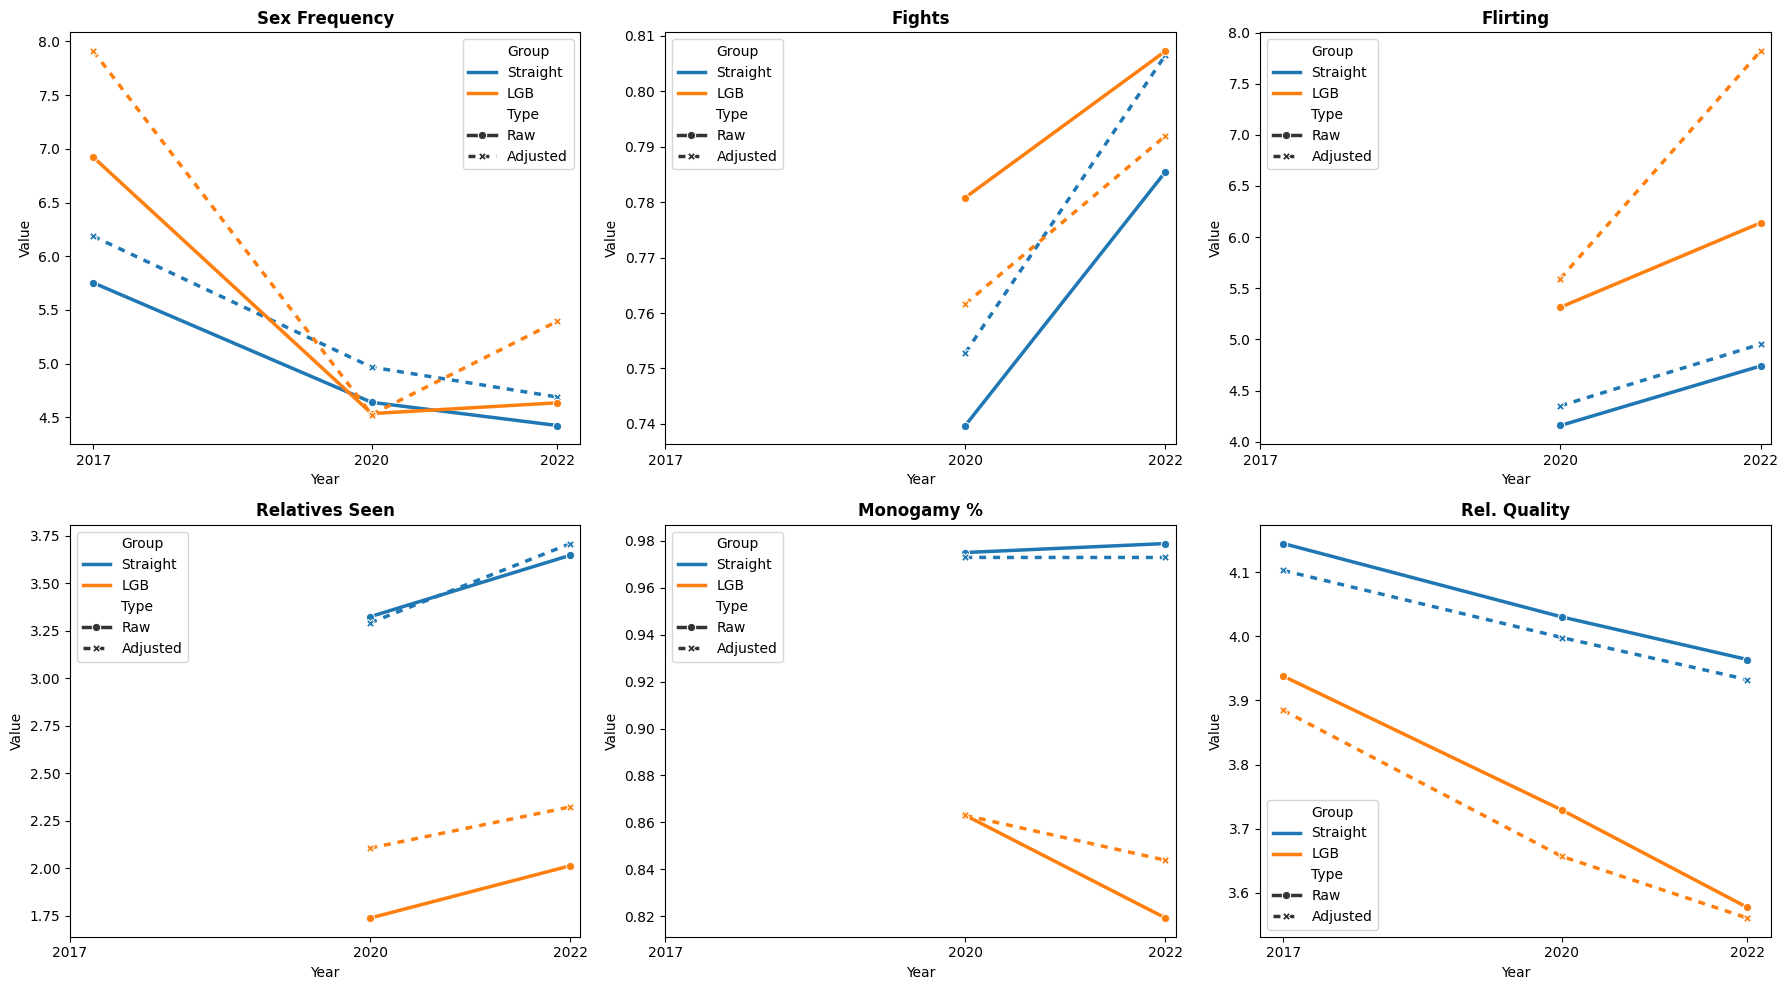

In [ ]:
# Create working df
behav_df = df.copy()

# Grouping
behav_df['group'] = behav_df['w1_identity_all_modified'].astype(str).apply(
    lambda x: 'LGB' if any(i in x.lower() for i in ['gay', 'lesbian', 'bisexual']) else 'Straight'
)

# Apply mappings and explicitly cast to float to avoid the Categorical error
for w in ['w1', 'w2', 'w3']:
    if f'{w}_sex_frequency' in behav_df.columns:
        behav_df[f'sex_val_{w}'] = behav_df[f'{w}_sex_frequency'].map(sex_map).astype(float)
    if f'{w}_fight' in behav_df.columns:
        behav_df[f'fight_val_{w}'] = behav_df[f'{w}_fight'].map(fight_map).astype(float)
    if f'{w}_flirt' in behav_df.columns:
        behav_df[f'flirt_val_{w}'] = behav_df[f'{w}_flirt'].map(flirt_map).astype(float)
    if f'{w}_relatives' in behav_df.columns:
        behav_df[f'rel_val_{w}'] = pd.to_numeric(behav_df[f'{w}_relatives'], errors='coerce')
    if f'{w}_p_monogamy' in behav_df.columns:
        behav_df[f'monog_val_{w}'] = behav_df[f'{w}_p_monogamy'].map(monog_map).astype(float)

# Quality Baseline
qual_map = {'Excellent': 5.0, 'Very Good': 4.0, 'Good': 3.0, 'Fair': 2.0, 'Poor': 1.0}
behav_df['q_w1'] = behav_df['w1_q34'].map(qual_map).astype(float)
behav_df['q_w2'] = behav_df['w2_rel_qual_combo'].map(qual_map).astype(float)
behav_df['q_w3'] = behav_df['w3_rel_qual'].map(qual_map).astype(float)

# --- 1. AGGREGATION & DATA PREP ---
metrics = ['sex_val', 'fight_val', 'flirt_val', 'rel_val', 'monog_val', 'q_w']
plot_rows = []

# --- 1. AGGREGATION & DATA PREP ---
metrics = ['sex_val', 'fight_val', 'flirt_val', 'rel_val', 'monog_val', 'q_w']
plot_rows = []


# --- A. Weighted Mean Function ---
def get_weighted_mean(df_subset, val_col, weight_col):
    mask = df_subset[val_col].notna() & df_subset[weight_col].notna()
    data = df_subset[mask]
    if len(data) == 0: return np.nan
    return np.average(data[val_col], weights=data[weight_col])

# --- B. Processing Loop (Double Calculation) ---
metrics = ['sex_val', 'fight_val', 'flirt_val', 'rel_val', 'monog_val', 'q_w']
plot_rows = []

for g in ['Straight', 'LGB']:
    group_subset = behav_df[behav_df['group'] == g]
    
    for w_key, year in {'w1': 2017, 'w2': 2020, 'w3': 2022}.items():
        for m in metrics:
            col = f'q_{w_key}' if m == 'q_w' else f'{m}_{w_key}'
            
            if col in group_subset.columns:
                # 1. Calculate RAW Mean
                raw_val = group_subset[col].mean()
                plot_rows.append({'Group': g, 'Year': year, 'Metric': m, 'Value': raw_val, 'Type': 'Raw'})
                
                # 2. Calculate ADJUSTED Mean
                adj_val = get_weighted_mean(group_subset, col, 'w1_weight_combo')
                plot_rows.append({'Group': g, 'Year': year, 'Metric': m, 'Value': adj_val, 'Type': 'Adjusted'})

summary_all = pd.DataFrame(plot_rows)

# --- C. Visualizing with Dashed Lines ---
# We will use 'linestyle' to show the Adjusted vs Raw
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

titles = ['Sex Frequency', 'Fights', 'Flirting', 'Relatives Seen', 'Monogamy %', 'Rel. Quality']
metric_keys = ['sex_val', 'fight_val', 'flirt_val', 'rel_val', 'monog_val', 'q_w']

for i, m in enumerate(metric_keys):
    subset = summary_all[summary_all['Metric'] == m]
    
    # Use 'style' to make the Adjusted line dashed
    sns.lineplot(ax=axes[i], data=subset, x='Year', y='Value', 
                 hue='Group', style='Type', 
                 markers=True, dashes={"Raw": "", "Adjusted": (2, 2)}, linewidth=2.5)
    
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].set_xticks([2017, 2020, 2022])

plt.tight_layout()
plt.show()

The "Intimacy Convergence": In 2017, LGB couples had significantly higher sex frequency. However, by 2020 (the pandemic), both groups "converged" to a lower baseline. This suggests that external stress (COVID-19) is a massive equalizer in intimacy.

The Fighting/Flirting Paradox: LGB couples show higher Monthly Fights and higher Monthly Flirting. This is a classic sign of a "high-affect" relationship—more conflict but also more active romantic maintenance. Straight relationships appear "quieter" on both fronts.

The Monogamy Gap: The drop in Monogamy Expectation for the LGB group (down to ~0.82) compared to the near-constant 0.98 for Straights is your most significant finding. It suggests that as LGB relationships mature, they are much more likely to negotiate non-monogamy.

Social Support: Straight couples see relatives nearly twice as often as LGB couples. This highlights the importance of "Chosen Family" in the LGB community, as traditional biological family ties appear less central.